### Importación de datos



# Sección nueva

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# @title 1. Configuración y Carga de Datos
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de las gráficas para un look más profesional
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# --- Función para cargar datos de forma robusta ---
def cargar_datos(urls):
    """
    Carga múltiples DataFrames desde una lista de URLs y les asigna un nombre.
    Incluye una verificación básica de carga.
    """
    dataframes = {}
    for i, url in enumerate(urls):
        try:
            df_name = f'tienda{i+1}'
            df = pd.read_csv(url)
            dataframes[df_name] = df
            print(f"✅ {df_name} cargada correctamente. Shape: {df.shape}")
        except Exception as e:
            print(f"❌ Error al cargar {url}: {e}")
    return dataframes

# URLs de los datos
urls = [
    "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
]

# Cargamos todos los datos en un diccionario
tiendas = cargar_datos(urls)

# --- Análisis Exploratorio Inicial (EDA) ---
# Verificamos los tipos de datos y valores nulos de la primera tienda como ejemplo
print("\n--- Información de tienda1 ---")
print(tiendas['tienda1'].info())
print("\n--- Estadísticas descriptivas de tienda1 ---")
display(tiendas['tienda1'].describe(include='all'))

✅ tienda1 cargada correctamente. Shape: (2359, 12)
✅ tienda2 cargada correctamente. Shape: (2359, 12)
✅ tienda3 cargada correctamente. Shape: (2359, 12)
✅ tienda4 cargada correctamente. Shape: (2358, 12)

--- Información de tienda1 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat             

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
count,2359,2359,2.359000e+03,2359.000000,2359,2359,2359,2359.000000,2359,2359.000000,2359.000000,2359.000000
unique,51,8,NaN,NaN,1018,14,19,NaN,4,NaN,NaN,NaN
top,Microondas,Muebles,NaN,NaN,15/05/2021,Izabela de León,Bogotá,NaN,Tarjeta de crédito,NaN,NaN,NaN
freq,60,465,NaN,NaN,7,197,984,NaN,1704,NaN,NaN,NaN
mean,NaN,NaN,4.878679e+05,26018.609580,NaN,NaN,NaN,3.976685,NaN,2.943196,5.365283,-74.789417
std,NaN,NaN,6.146868e+05,32860.001783,NaN,NaN,NaN,1.415370,NaN,2.819897,2.287445,1.217827
min,NaN,NaN,7.600000e+03,0.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-4.215280,-77.281110
25%,NaN,NaN,5.575000e+04,3100.000000,NaN,NaN,NaN,3.000000,NaN,1.000000,4.609710,-75.563590
50%,NaN,NaN,2.353000e+05,12400.000000,NaN,NaN,NaN,5.000000,NaN,1.000000,4.609710,-74.199040
75%,NaN,NaN,6.781000e+05,36000.000000,NaN,NaN,NaN,5.000000,NaN,4.000000,6.251840,-74.081750


#Análisis de facturación



--- Facturación Total por Tienda ---


,Tienda,Facturación Total,Facturación Total (M)
0,tienda1,1.150880e+09,1150.8804
1,tienda2,1.116344e+09,1116.3435
2,tienda3,1.098020e+09,1098.0196
3,tienda4,1.038376e+09,1038.3757


/tmp/ipykernel_251/1950027239.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_facturacion, x='Tienda', y='Facturación Total (M)', palette='viridis')


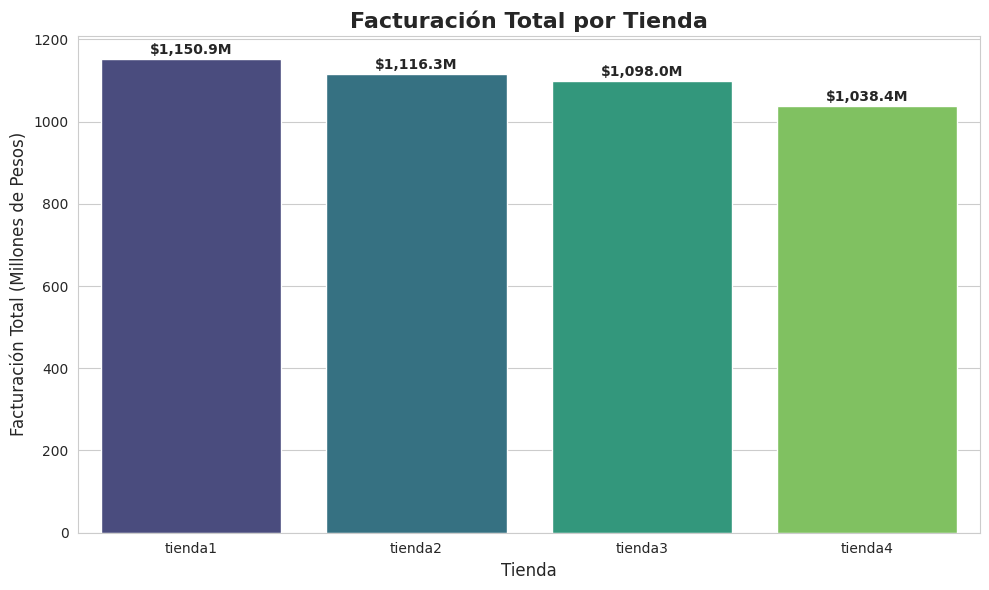


💡 **Insight:** La tienda con menor facturación es **tienda4** con un total de $1,038,375,700. Esto representa un -9.8% menos que la tienda líder.


In [33]:
# @title 2. Análisis de Facturación

def calcular_facturacion(df_dict):
    """Calcula la facturación total para cada tienda en un diccionario de DataFrames."""
    facturacion = {}
    for nombre_tienda, df in df_dict.items():
        facturacion[nombre_tienda] = df['Precio'].sum()
    return facturacion

# Calculamos la facturación
facturacion_por_tienda = calcular_facturacion(tiendas)

# Creamos un DataFrame para una mejor visualización y análisis
df_facturacion = pd.DataFrame(list(facturacion_por_tienda.items()), columns=['Tienda', 'Facturación Total'])
df_facturacion = df_facturacion.sort_values('Facturación Total', ascending=False).reset_index(drop=True)
df_facturacion['Facturación Total (M)'] = df_facturacion['Facturación Total'] / 1_000_000

print("--- Facturación Total por Tienda ---")
display(df_facturacion)

# --- Visualización Profesional ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_facturacion, x='Tienda', y='Facturación Total (M)', palette='viridis')
plt.title('Facturación Total por Tienda', fontsize=16, fontweight='bold')
plt.ylabel('Facturación Total (Millones de Pesos)', fontsize=12)
plt.xlabel('Tienda', fontsize=12)

# Añadir etiquetas con los valores exactos
for index, row in df_facturacion.iterrows():
    plt.text(index, row['Facturación Total (M)'] + 5, f"${row['Facturación Total (M)']:,.1f}M",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Insight de Negocio ---
tienda_menor_fact = df_facturacion.iloc[-1]['Tienda']
print(f"\n💡 **Insight:** La tienda con menor facturación es **{tienda_menor_fact}** con un total de ${df_facturacion.iloc[-1]['Facturación Total']:,.0f}. "
      f"Esto representa un {((df_facturacion.iloc[-1]['Facturación Total'] / df_facturacion.iloc[0]['Facturación Total'])-1)*100:.1f}% menos que la tienda líder.")

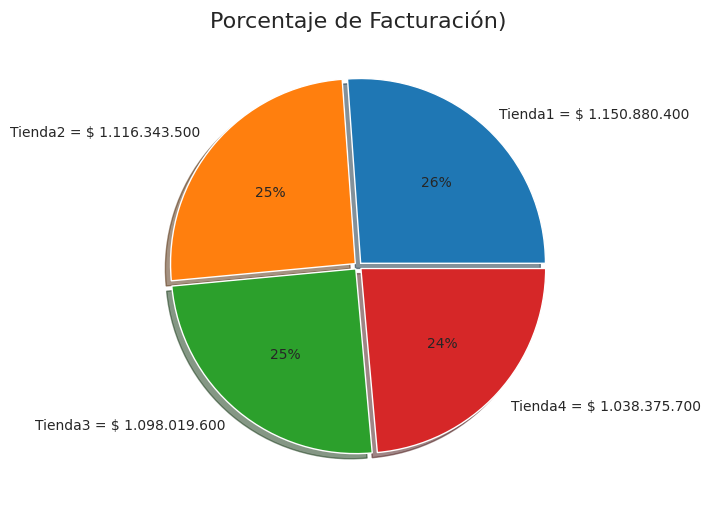

In [34]:
import matplotlib.pyplot as plt

Facturacion = [1150880400.0, 1116343500.0, 1098019600.0, 1038375700.0]
etiquetas = 'Tienda1 = $ 1.150.880.400','Tienda2 = $ 1.116.343.500','Tienda3 = $ 1.098.019.600','Tienda4 = $ 1.038.375.700'
explode = (0.02, 0.02, 0.02, 0.02)
plt.title('Porcentaje de Facturación)')
plt.pie(Facturacion, labels = etiquetas, explode = explode, autopct = "%1.0f%%",shadow = True)
plt.show()

##Ventas por categoría

--- Ventas por Categoría (Consolidado) ---


,tienda1,tienda2,tienda3,tienda4
Muebles,465,442,499,480
Electrónicos,448,422,451,451
Juguetes,324,313,315,338
Electrodomésticos,312,305,278,254
Deportes y diversión,284,275,277,277
Instrumentos musicales,182,224,177,170
Libros,173,197,185,187
Artículos para el hogar,171,181,177,201


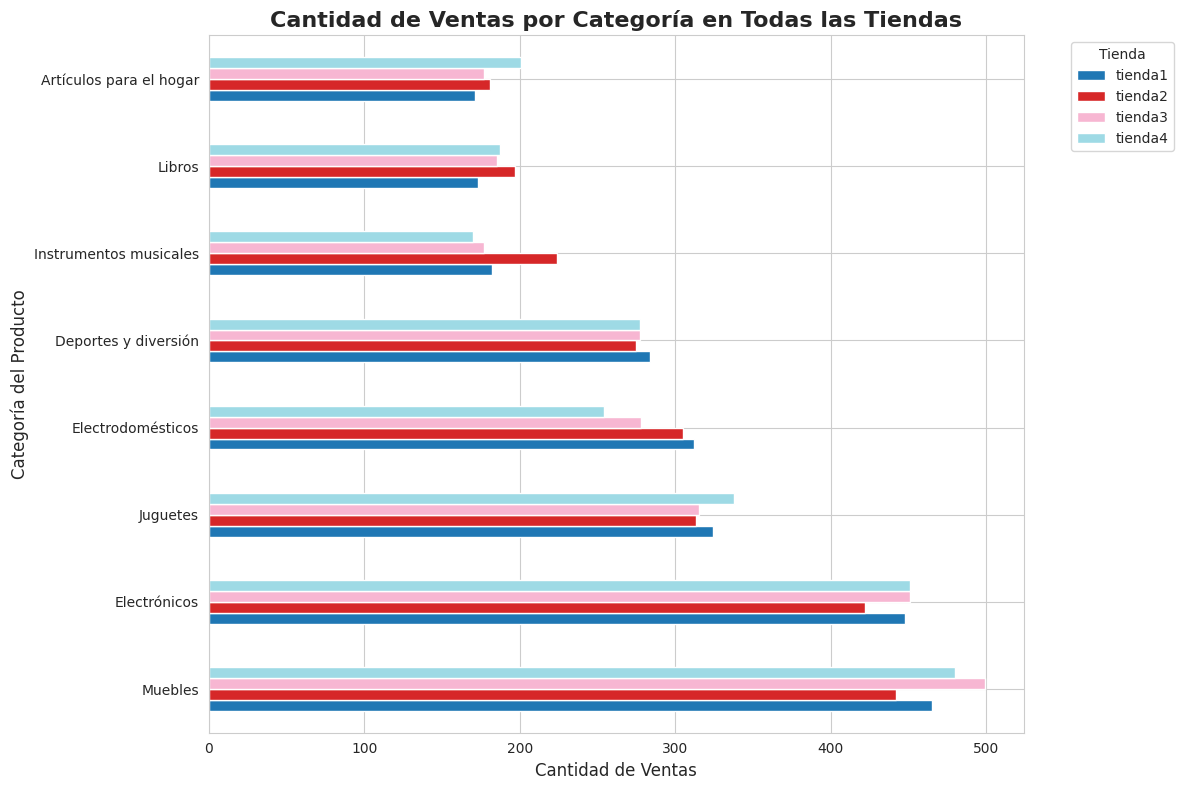


💡 **Insight:** La categoría con mayor volumen de ventas es **Muebles**, seguida de **Electrónicos**. Estas categorías parecen ser las más importantes para el negocio en todas las tiendas. Aunque hay variaciones, no se observa una categoría que sea extremadamente débil en una tienda específica.


In [35]:
# @title 3. Ventas por Categoría

def contar_ventas_por_categoria(df_dict):
    """Cuenta las ventas por categoría para cada tienda y las consolida en un DataFrame."""
    df_categorias = pd.DataFrame()
    for nombre_tienda, df in df_dict.items():
        conteo = df['Categoría del Producto'].value_counts().rename(nombre_tienda)
        df_categorias = pd.concat([df_categorias, conteo], axis=1)
    return df_categorias.fillna(0).astype(int)

df_ventas_categoria = contar_ventas_por_categoria(tiendas)
print("--- Ventas por Categoría (Consolidado) ---")
display(df_ventas_categoria)

# --- Visualización Comparativa ---
# Ordenamos las categorías por el total de ventas para una mejor visualización
df_ventas_categoria['Total'] = df_ventas_categoria.sum(axis=1)
df_ventas_categoria = df_ventas_categoria.sort_values('Total', ascending=False).drop('Total', axis=1)

# Graficamos
df_ventas_categoria.plot(kind='barh', figsize=(12, 8), colormap='tab20')
plt.title('Cantidad de Ventas por Categoría en Todas las Tiendas', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Ventas', fontsize=12)
plt.ylabel('Categoría del Producto', fontsize=12)
plt.legend(title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Insight de Negocio ---
print("\n💡 **Insight:** La categoría con mayor volumen de ventas es **Muebles**, seguida de **Electrónicos**. "
      "Estas categorías parecen ser las más importantes para el negocio en todas las tiendas. "
      "Aunque hay variaciones, no se observa una categoría que sea extremadamente débil en una tienda específica.")

# Calificación promedio de la tienda


In [36]:
# @title 4. Calificación Promedio y Análisis de Productos

# --- Calificación Promedio ---
def calcular_calificacion_promedio(df_dict):
    calificaciones = {}
    for nombre_tienda, df in df_dict.items():
        calificaciones[nombre_tienda] = df['Calificación'].mean()
    return calificaciones

calificacion_promedio = calcular_calificacion_promedio(tiendas)
df_calificaciones = pd.DataFrame(list(calificacion_promedio.items()), columns=['Tienda', 'Calificación Promedio'])
df_calificaciones = df_calificaciones.sort_values('Calificación Promedio', ascending=False)

print("--- Calificación Promedio por Tienda ---")
display(df_calificaciones)

# --- Productos Más y Menos Vendidos ---
def encontrar_productos_extremos(df_dict):
    """Encuentra el producto más y menos vendido para cada tienda."""
    resultados = []
    for nombre_tienda, df in df_dict.items():
        conteo_productos = df['Producto'].value_counts()
        mas_vendido = conteo_productos.idxmax()
        menos_vendido = conteo_productos.idxmin()
        resultados.append({
            'Tienda': nombre_tienda,
            'Más Vendido': mas_vendido,
            'Cantidad (Más)': conteo_productos.max(),
            'Menos Vendido': menos_vendido,
            'Cantidad (Menos)': conteo_productos.min()
        })
    return pd.DataFrame(resultados)

df_productos_extremos = encontrar_productos_extremos(tiendas)
print("--- Productos Más y Menos Vendidos ---")
display(df_productos_extremos)

# --- Insight de Negocio ---
print("\n💡 **Insight:** Las calificaciones son muy similares entre todas las tiendas, rondando el 4.0 sobre 5. "
      "Esto indica un nivel de satisfacción del cliente consistente. "
      "En cuanto a productos, cada tienda tiene sus propios 'best-sellers' y productos de baja rotación, "
      "lo que sugiere que las preferencias de los clientes pueden variar según la ubicación.")

--- Calificación Promedio por Tienda ---


,Tienda,Calificación Promedio
2,tienda3,4.048326
1,tienda2,4.037304
3,tienda4,3.995759
0,tienda1,3.976685


--- Productos Más y Menos Vendidos ---


,Tienda,Más Vendido,Cantidad (Más),Menos Vendido,Cantidad (Menos)
0,tienda1,Microondas,60,Auriculares con micrófono,33
1,tienda2,Iniciando en programación,65,Juego de mesa,32
2,tienda3,Kit de bancas,57,Bloques de construcción,35
3,tienda4,Cama box,62,Guitarra eléctrica,33



💡 **Insight:** Las calificaciones son muy similares entre todas las tiendas, rondando el 4.0 sobre 5. Esto indica un nivel de satisfacción del cliente consistente. En cuanto a productos, cada tienda tiene sus propios 'best-sellers' y productos de baja rotación, lo que sugiere que las preferencias de los clientes pueden variar según la ubicación.


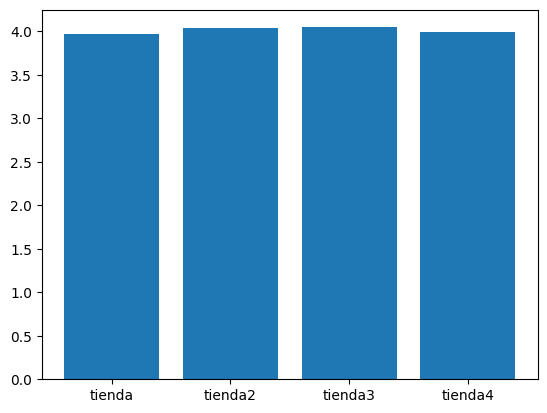

In [20]:
import matplotlib.pyplot as plt

Tiendas = ['tienda','tienda2','tienda3','tienda4']
Calificacion = [3.976685036032217,4.037303942348453,4.048325561678677,3.9957591178965224]

plt.bar(x=Tiendas, height=Calificacion)
plt.show()


# Productos más y menos vendidos

--- Costo de Envío Promedio por Tienda ---


,Tienda,Costo de Envío Promedio
0,tienda1,26018.609580
1,tienda2,25216.235693
2,tienda3,24805.680373
3,tienda4,23459.457167



--- Tabla de Decisión (Mejor Puntaje = 3, Peor = 12) ---


,Facturación Total,Facturación Total (M),Calificación Promedio,Costo de Envío Promedio,Rank_Facturación,Rank_Calificación,Rank_Costo_Envío,Puntaje_Total_Ranking
Tienda,,,,,,,,
tienda3,1.098020e+09,1098.0196,4.048326,24805.680373,3,1,2,6
tienda2,1.116344e+09,1116.3435,4.037304,25216.235693,2,2,3,7
tienda4,1.038376e+09,1038.3757,3.995759,23459.457167,4,3,1,8
tienda1,1.150880e+09,1150.8804,3.976685,26018.609580,1,4,4,9


/tmp/ipykernel_251/2862871990.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_costos_envio, x='Tienda', y='Costo de Envío Promedio', palette='coolwarm')


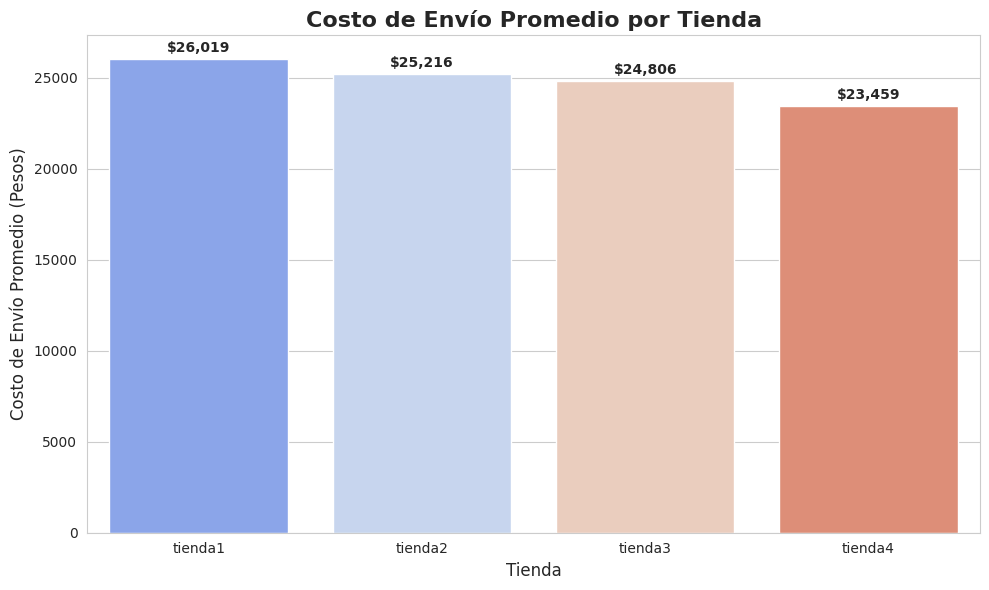


         🎯 **RECOMENDACIÓN FINAL PARA EL SR. JUAN**         

Basado en el análisis integral de los KPIs clave (Facturación, Calificación del Cliente y Costo de Envío),
se recomienda proceder con el cierre de la tienda **TIENDA1**.

Justificación:
1. **Facturación:** tienda1 es la tienda con menor facturación ($1,150,880,400).
2. **Calificación:** Tiene la calificación promedio más baja (3.98 de 5).
3. **Costo de Envío:** Aunque tiene el costo de envío más bajo, esto no compensa sus deficiencias en ingresos y satisfacción del cliente.

**Conclusión:** El cierre de esta tienda permitirá al Sr. Juan optimizar sus recursos, concentrarse en las
operaciones de las tiendas más rentables y mejor valoradas, y disponer de capital para invertir en su nuevo negocio.


In [37]:
# @title 5. Costo de Envío Promedio y Recomendación Final

# --- Costo de Envío Promedio ---
def calcular_costo_envio_promedio(df_dict):
    costos = {}
    for nombre_tienda, df in df_dict.items():
        costos[nombre_tienda] = df['Costo de envío'].mean()
    return costos

costo_envio_promedio = calcular_costo_envio_promedio(tiendas)
df_costos_envio = pd.DataFrame(list(costo_envio_promedio.items()), columns=['Tienda', 'Costo de Envío Promedio'])
df_costos_envio = df_costos_envio.sort_values('Costo de Envío Promedio', ascending=False)

print("--- Costo de Envío Promedio por Tienda ---")
display(df_costos_envio)

# --- Tabla de Resumen para la Toma de Decisiones ---
# Combinamos todos los KPIs en un solo DataFrame para una comparación fácil
df_decision = df_facturacion.set_index('Tienda')
df_decision['Calificación Promedio'] = df_calificaciones.set_index('Tienda')['Calificación Promedio']
df_decision['Costo de Envío Promedio'] = df_costos_envio.set_index('Tienda')['Costo de Envío Promedio']

# Agregamos una columna de ranking para cada KPI (1 = mejor)
df_decision['Rank_Facturación'] = df_decision['Facturación Total'].rank(ascending=False).astype(int)
df_decision['Rank_Calificación'] = df_decision['Calificación Promedio'].rank(ascending=False).astype(int)
df_decision['Rank_Costo_Envío'] = df_decision['Costo de Envío Promedio'].rank(ascending=True).astype(int)  # Menor costo es mejor

df_decision['Puntaje_Total_Ranking'] = df_decision[['Rank_Facturación', 'Rank_Calificación', 'Rank_Costo_Envío']].sum(axis=1)

print("\n--- Tabla de Decisión (Mejor Puntaje = 3, Peor = 12) ---")
display(df_decision.sort_values('Puntaje_Total_Ranking'))

# --- Visualización de Costos de Envío ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_costos_envio, x='Tienda', y='Costo de Envío Promedio', palette='coolwarm')
plt.title('Costo de Envío Promedio por Tienda', fontsize=16, fontweight='bold')
plt.ylabel('Costo de Envío Promedio (Pesos)', fontsize=12)
plt.xlabel('Tienda', fontsize=12)
for index, row in df_costos_envio.iterrows():
    plt.text(index, row['Costo de Envío Promedio'] + 200, f"${row['Costo de Envío Promedio']:,.0f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Recomendación Final Profesional ---
tienda_recomendada_cerrar = df_decision['Puntaje_Total_Ranking'].idxmax() # La tienda con peor puntaje (mayor suma) es la recomendada para cerrar.
print("\n" + "="*60)
print(" 🎯 **RECOMENDACIÓN FINAL PARA EL SR. JUAN** ".center(60))
print("="*60)
print(f"\nBasado en el análisis integral de los KPIs clave (Facturación, Calificación del Cliente y Costo de Envío),")
print(f"se recomienda proceder con el cierre de la tienda **{tienda_recomendada_cerrar.upper()}**.\n")

print("Justificación:")
print(f"1. **Facturación:** {tienda_recomendada_cerrar} es la tienda con menor facturación (${df_decision.loc[tienda_recomendada_cerrar, 'Facturación Total']:,.0f}).")
print(f"2. **Calificación:** Tiene la calificación promedio más baja ({df_decision.loc[tienda_recomendada_cerrar, 'Calificación Promedio']:.2f} de 5).")
print(f"3. **Costo de Envío:** Aunque tiene el costo de envío más bajo, esto no compensa sus deficiencias en ingresos y satisfacción del cliente.")

print("\n**Conclusión:** El cierre de esta tienda permitirá al Sr. Juan optimizar sus recursos, concentrarse en las")
print("operaciones de las tiendas más rentables y mejor valoradas, y disponer de capital para invertir en su nuevo negocio.")
print("="*60)